In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
# 1) Data Loading and Preparation

data = pd.read_excel("D:/Ruslan/main.xlsx")
print(data.head())
print("Unique conditions (raw):", data['Condition'].unique())

# Label-encode the 'Condition' column (even if not used in regression, it may be helpful)
labelencoder = LabelEncoder()
data['Condition'] = labelencoder.fit_transform(data['Condition'])
print("Unique conditions (encoded):", data['Condition'].unique())

# Construct full file paths for images and store in 'ImagePath'
image_dir = "D:/Ruslan/main/"
data['ImagePath'] = data['IMG name'].apply(
    lambda x: os.path.join(image_dir, f"{x}.jpg")
)
print(data[['IMG name', 'Condition', 'ImagePath']].head())

   IMG name  Voltage, V  Current, A Condition
0         1       20.21       2.000     clean
1         2       20.27       2.006     clean
2         3       20.33       2.010     clean
3         4       20.33       2.009     clean
4         5       20.32       2.007     clean
Unique conditions (raw): ['clean' 'water' 'dust' 'snow']
Unique conditions (encoded): [0 3 1 2]
   IMG name  Condition             ImagePath
0         1          0  D:/Ruslan/main/1.jpg
1         2          0  D:/Ruslan/main/2.jpg
2         3          0  D:/Ruslan/main/3.jpg
3         4          0  D:/Ruslan/main/4.jpg
4         5          0  D:/Ruslan/main/5.jpg


In [ ]:
# Custom split logic based on condition & IMG name
def assign_split(row):
    img_name = row['IMG name']
    cond = row['Condition']
    # Hard-coded split logic per condition
    if cond == 0:  # clean
        if 428 <= img_name <= 603:
            return 'test'
        else:
            return 'train_val'
    elif cond == 3:  # water
        if 1006 <= img_name <= 1156:
            return 'test'
        else:
            return 'train_val'
    elif cond == 1:  # dust
        if 2901 <= img_name <= 3029:
            return 'test'
        else:
            return 'train_val'
    elif cond == 2:  # snow
        if 3370 <= img_name <= 3630:
            return 'test'
        else:
            return 'train_val'
    else:
        return 'train_val'

data['Split'] = data.apply(assign_split, axis=1)
test_data = data[data['Split'] == 'test'].copy()
train_val_data = data[data['Split'] == 'train_val'].copy()

In [4]:

# Split train_val_data into train and validation sets
train_data, val_data = train_test_split(
    train_val_data, test_size=0.1875,
    random_state=42,
    stratify=train_val_data['Condition']
)

print("Train data size:", train_data.shape[0])
print("Validation data size:", val_data.shape[0])
print("Test data size:", test_data.shape[0])

Train data size: 2846
Validation data size: 657
Test data size: 717


In [5]:
# =============================================================================
# 2) tf.data Pipeline for Regression
# =============================================================================
IMG_SIZE = (224, 224)

def load_image_and_labels(filename, condition, voltage, current, augment=False):
    """
    Load + decode + resize. Optionally apply augmentation.
    Returns (image, label_dict) where the regression labels are stacked.
    """
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    # Stack the regression targets: Voltage and Current
    regression_values = tf.stack([voltage, current], axis=-1)
    return image, {'regression': regression_values}

def df_to_dataset(df, shuffle=True, batch_size=32, augment=False):
    filenames = df['ImagePath'].values
    conditions = df['Condition'].values  # Not used in regression but available
    voltages = df['Voltage, V'].values
    currents = df['Current, A'].values

    ds = tf.data.Dataset.from_tensor_slices((filenames, conditions, voltages, currents))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)
    ds = ds.map(lambda f, c, v, i: load_image_and_labels(f, c, v, i, augment=augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


In [ ]:
# Create datasets
train_ds = df_to_dataset(train_data, shuffle=True, batch_size=32, augment=False)
val_ds   = df_to_dataset(val_data,   shuffle=False, batch_size=32, augment=False)
test_ds  = df_to_dataset(test_data,  shuffle=False, batch_size=32, augment=False)

In [ ]:
# 3) Define Custom R² Metric for Regression
# =============================================================================
class RSquaredMetric(metrics.Metric):
    def __init__(self, name="r_squared", **kwargs):
        super().__init__(name=name, **kwargs)
        self.total_sum_of_squares = self.add_weight(name="total_ss", initializer="zeros")
        self.residual_sum_of_squares = self.add_weight(name="residual_ss", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        residuals = y_true - y_pred
        total = y_true - tf.reduce_mean(y_true)
        self.residual_sum_of_squares.assign_add(tf.reduce_sum(tf.square(residuals)))
        self.total_sum_of_squares.assign_add(tf.reduce_sum(tf.square(total)))

    def result(self):
        r2 = 1 - (self.residual_sum_of_squares / self.total_sum_of_squares)
        return r2

    def reset_states(self):
        self.total_sum_of_squares.assign(0.0)
        self.residual_sum_of_squares.assign(0.0)

In [ ]:
# 4) Define ResNet-18 Pre-Activation Regression Architecture
# =============================================================================
def preact_basic_block(x, filters, stride=1, downsample=False, name="preact_block"):
    """
    A single pre-activation residual block (ResNet v2 style).
    """
    shortcut = x

    # Pre-activation: BN -> ReLU
    x = layers.BatchNormalization(name=name + "_bn1")(x)
    x = layers.ReLU(name=name + "_relu1")(x)

    # Projection shortcut for dimension / spatial downsampling if needed
    if downsample:
        shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride,
                                 padding='same', use_bias=False,
                                 name=name + "_proj")(x)

    # First 3x3 convolution
    x = layers.Conv2D(filters, kernel_size=3, strides=stride, padding='same',
                      use_bias=False, name=name + "_conv1")(x)

    # Second pre-activation: BN -> ReLU
    x = layers.BatchNormalization(name=name + "_bn2")(x)
    x = layers.ReLU(name=name + "_relu2")(x)

    # Second 3x3 convolution (stride 1)
    x = layers.Conv2D(filters, kernel_size=3, strides=1, padding='same',
                      use_bias=False, name=name + "_conv2")(x)

    # Residual addition
    x = layers.Add(name=name + "_add")([x, shortcut])
    return x

In [ ]:
def build_resnet18_pre_activation_regression(input_shape=(224, 224, 3), num_regression_outputs=2):
    """
    Builds a ResNet-18 model with pre-activation residual blocks adapted for regression.
    """
    inputs = layers.Input(shape=input_shape)

    # Initial Convolution: 7x7 conv, stride=2, followed by BN, ReLU, and max pooling.
    x = layers.Conv2D(64, kernel_size=7, strides=2, padding='same',
                      use_bias=False, name="conv1")(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.ReLU(name="relu1")(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same', name="maxpool1")(x)

    # Define the number of blocks and filters per stage for ResNet-18
    filters_list = [64, 128, 256, 512]
    blocks_per_stage = [2, 2, 2, 2]
     # Build stages using preactivation residual blocks
    for stage_idx, (filters, num_blocks) in enumerate(zip(filters_list, blocks_per_stage)):
        for block_idx in range(num_blocks):
            # Downsample (stride=2) at the beginning of each stage except stage 0
            stride = 2 if (block_idx == 0 and stage_idx > 0) else 1
            downsample = True if (block_idx == 0 and stage_idx > 0) else False
            block_name = f"stage{stage_idx+1}_block{block_idx+1}"
            x = preact_basic_block(
                x, filters=filters, stride=stride,
                downsample=downsample, name=block_name
            )

    # Final BN and ReLU (making the after-addition activation an identity for the residual branch)
    x = layers.BatchNormalization(name="bn_final")(x)
    x = layers.ReLU(name="relu_final")(x)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)

    # Regression head: Dense layer with linear activation (num_regression_outputs=2)
    outputs = layers.Dense(num_regression_outputs, activation='linear', name="regression")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="ResNet18_Preact_Regression")
    return model

In [ ]:
# 5) Instantiate, Compile, and Train the Model
# =============================================================================
model = build_resnet18_pre_activation_regression(input_shape=(224, 224, 3), num_regression_outputs=2)
model.summary()

# Instantiate the custom R² metric
r_squared_metric = RSquaredMetric()

# Compile the model for regression
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=losses.MeanSquaredError(),
    metrics=[losses.MeanSquaredError(), r_squared_metric]
)

# Setup callbacks: ModelCheckpoint and EarlyStopping
save_dir = "D:/Ruslan/ModelWeights/"
os.makedirs(save_dir, exist_ok=True)
weights_path = os.path.join(save_dir, "resnet18_preact_regression_weights_epoch200_224x224.h5")

checkpoint_cb = ModelCheckpoint(
    filepath=weights_path,
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)
early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=200,
    restore_best_weights=True,
    verbose=1
)

# Train the model
with tf.device('/GPU:0'):
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=200,
        callbacks=[checkpoint_cb, early_stopping_cb]
    )

Model: "ResNet18_Preact_Regression"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1 (Conv2D)                 (None, 112, 112, 64  9408        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn1 (BatchNormalization)       (None, 112, 112, 64  256         ['conv1[0][0]']                  
                                )                                        

c:\Users\lab311\miniconda3\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric RSquaredMetric implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()



Epoch 1: val_loss improved from inf to 89.21548, saving model to D:/Ruslan/ModelWeights\resnet18_preact_regression_weights_epoch200_224x224.h5
89/89 [==============================] - 220s 2s/step - loss: 87.4763 - mean_squared_error: 87.4674 - r_squared: -0.2970 - val_loss: 89.2155 - val_mean_squared_error: 89.0522 - val_r_squared: -0.3091
Epoch 2/200
89/89 [==============================] - ETA: 0s - loss: 44.2949 - mean_squared_error: 44.2821 - r_squared: 0.3434
Epoch 2: val_loss improved from 89.21548 to 75.27084, saving model to D:/Ruslan/ModelWeights\resnet18_preact_regression_weights_epoch200_224x224.h5
89/89 [==============================] - 217s 2s/step - loss: 44.2949 - mean_squared_error: 44.2821 - r_squared: 0.3434 - val_loss: 75.2708 - val_mean_squared_error: 75.1411 - val_r_squared: -0.1044
Epoch 3/200
89/89 [==============================] - ETA: 0s - loss: 29.4062 - mean_squared_error: 29.4065 - r_squared: 0.5641
Epoch 3: val_loss improved from 75.27084 to 51.61670, s

In [ ]:
# 6) Evaluate the Model on the Test Set
# =============================================================================
test_results = model.evaluate(test_ds)
print(f"Test Loss: {test_results[0]:.4f}, Test MSE: {test_results[1]:.4f}, Test R^2: {test_results[2]:.4f}")

23/23 [==============================] - 44s 2s/step - loss: 25.5771 - mean_squared_error: 25.3958 - r_squared: -0.1621
Test Loss: 25.5771, Test MSE: 25.3958, Test R^2: -0.1621


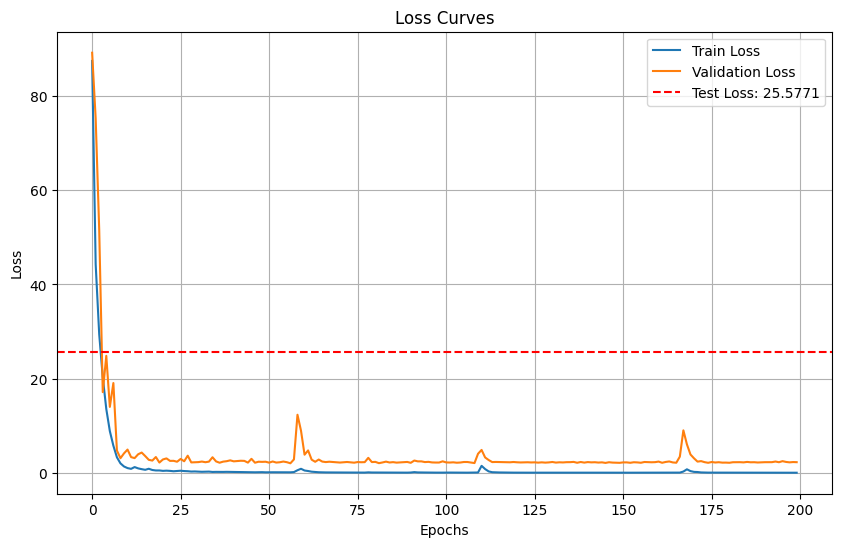

In [12]:
# 7) Plot Training Curves
# =============================================================================
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.axhline(test_results[0], color='red', linestyle='--', label=f'Test Loss: {test_results[0]:.4f}')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


1/1 [==============================] - 0s 350ms/step


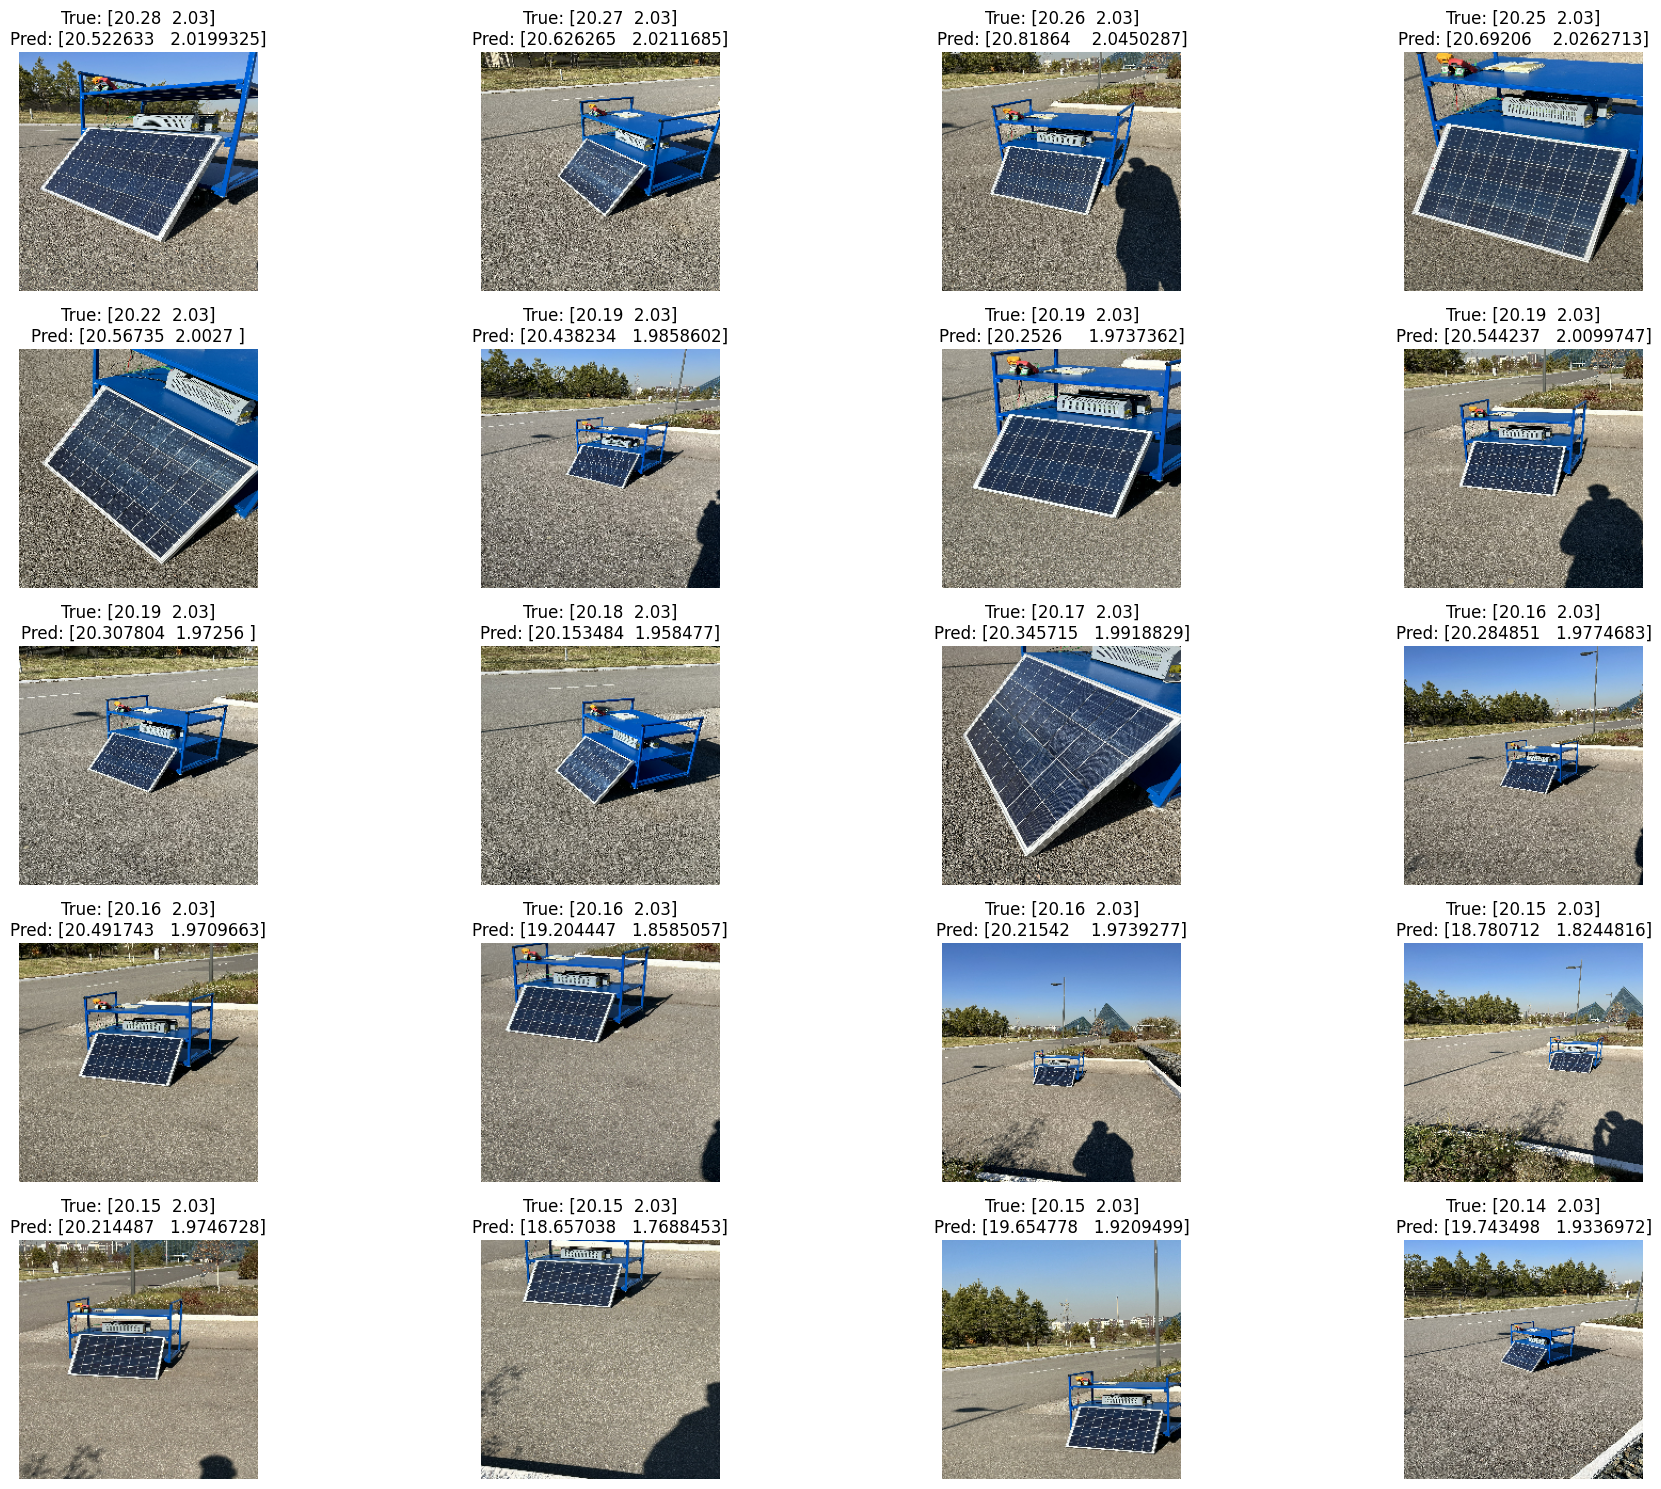

In [ ]:
# 8) Display Sample Predictions
# =============================================================================
def show_sample_predictions(test_ds, model, sample_count=20):
    """
    Display a few test images along with their true and predicted regression values.
    """
    images = []
    true_values = []
    pred_values = []
    count = 0

    # Iterate through the dataset until sample_count images are collected
    for image_batch, label_batch in test_ds:
        predictions = model.predict(image_batch)
        for i in range(image_batch.shape[0]):
            if count >= sample_count:
                break
            images.append(image_batch[i].numpy())
            # The regression labels are stored in the 'regression' key
            true_values.append(label_batch['regression'].numpy()[i])
            pred_values.append(predictions[i])
            count += 1
        if count >= sample_count:
            break

    # Plot the images with true vs predicted regression outputs
    fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 15))
    axes = axes.flatten()
    for idx, ax in enumerate(axes[:sample_count]):
        ax.imshow(images[idx])
        ax.axis('off')
        ax.set_title(f"True: {true_values[idx]}\nPred: {pred_values[idx]}")
    plt.tight_layout()
    plt.show()
    
show_sample_predictions(test_ds, model, sample_count=20)

1/1 [==============================] - 0s 28ms/step


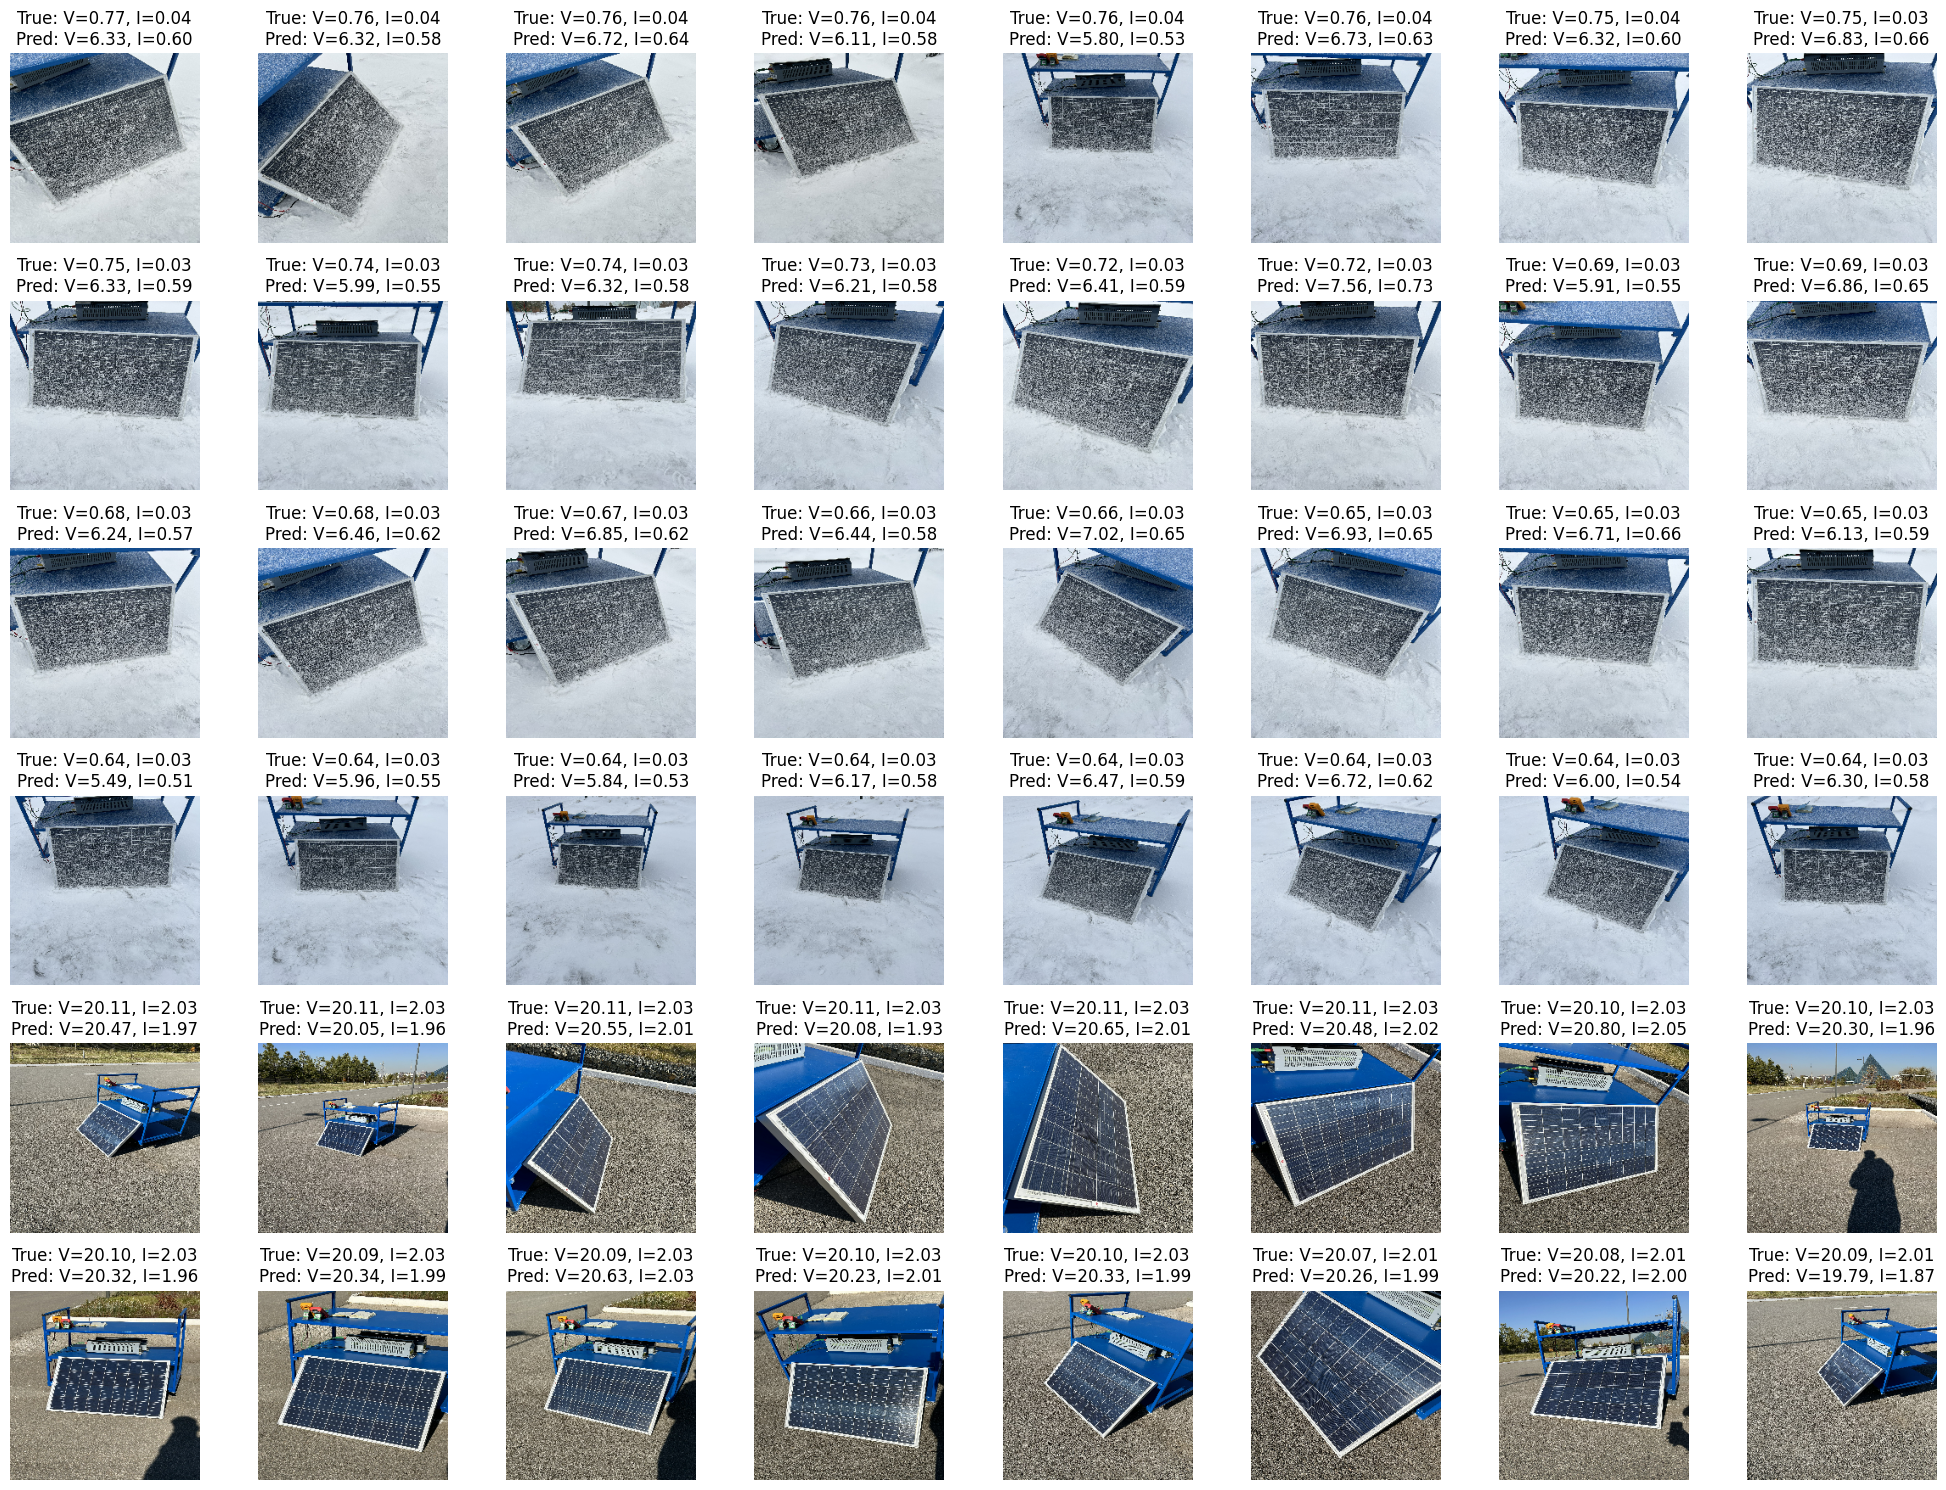

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def show_sample_predictions(test_ds, model, sample_count=48):
    images = []
    true_values = []
    predicted_values = []

    count = 0
    # Shuffle the dataset before sampling images
    test_ds = test_ds.shuffle(buffer_size=1000)  
    
    for image_batch, label_batch in test_ds:
        batch_size = image_batch.shape[0]
        predictions = model.predict(image_batch)
        
        for i in range(batch_size):
            if count >= sample_count:
                break
            images.append(image_batch[i].numpy())
            true_values.append(label_batch['regression'].numpy()[i])  # True regression values (voltage, current)
            predicted_values.append(predictions[i])  # Predicted regression values (voltage, current)
            count += 1
        
        if count >= sample_count:
            break

    # Adjust the figure size to make the images larger
    fig, axes = plt.subplots(nrows=6, ncols=8, figsize=(20, 15))  # Increase figsize for larger images
    axes = axes.flatten()

    for idx, ax in enumerate(axes[:sample_count]):
        ax.imshow(images[idx])
        ax.axis('off')
        
        # Extract true and predicted regression values
        true_voltage, true_current = true_values[idx]
        pred_voltage, pred_current = predicted_values[idx]
        
        # Set the title to show true vs predicted values for voltage and current
        ax.set_title(f"True: V={true_voltage:.2f}, I={true_current:.2f}\n"
                     f"Pred: V={pred_voltage:.2f}, I={pred_current:.2f}")

    plt.tight_layout()
    plt.show()

# Show predictions for 48 images
show_sample_predictions(test_ds, model, sample_count=48)
